![](https://img.shields.io/badge/CNES_AVISO-Contribution-%20?color=grey&labelColor=blue)

# SWOT L3 KaRIn and Nadir Ocean Data Products
This tutorial will introduce you to some sample SWOT L3 data products and show you how to download these data from AVISO and perform basic plots using Python related libraries.

The Sea Level Anomaly is represented by the `SSHA` fields in L3 LR SSH products. These fields are described as follow:

| SLA field | Calibrated | Edited | Filtered |
| --- | --- | --- | --- |
| ssha_unedited  | X | | |
|      ssha_unfiltered      | X | X | |
| ssha_filtered | X | X | X |


<div class="alert alert-info"><b>Note</b><p>

Environment needed to run this notebook:

* ``xarray``
* ``matplotlib``+``cartopy``
* ``altimetry_downloader_aviso``
* ``altimetry.io``
</p></div>

## Tutorial Objectives
* Present SWOT sample L3 data products (Basic and Expert versions)
* Download locally SWOT KaRIn (2D swath) and nadir (along-track) altimetry combined data using the ``altimetry_downloader_aviso``
* Show you how to query SWOT Sea Level Anomaly (SLA) data sets (nadir+swath, only nadir) using ``altimetry.io``
* How to visualise data using ``matplotlib``

## Import + code



In [1]:
# Install Cartopy with mamba to avoid discrepancies
# ! mamba install -q -c conda-forge cartopy

In [2]:
# Configure logging if you want more details
import logging
logging.basicConfig(level=logging.INFO)

In [3]:
from pathlib import Path

import cartopy.crs as ccrs
import cartopy.feature as cft
import cartopy.mpl.geoaxes as cmplgeo
import cartopy.mpl.gridliner as cmplgrid
import matplotlib.pyplot as plt

%matplotlib inline

## Parameters
Define a local filepath to download files

In [4]:
output_dir= Path.home() / "TMP_DATA"

In [5]:
cycle_number = 34
pass_number = 39

In [6]:
# California
bbox = (233, 35, 237, 42)
localbox = [233, 237, 35, 42]

## Download data using ``altimetry_downloader_aviso``

In [7]:
import altimetry_downloader_aviso as dl_aviso

### Consult Aviso's catalog

In [8]:
cat = dl_aviso.summary()

INFO:altimetry_downloader_aviso.catalog_client.client:Fetching products from Aviso's catalog...


In [9]:
for product in cat.products:
    print(f"{product.short_name}  {product.title}")

SWOT_L3_LR_WIND_WAVE_Light  Wind & Wave product SWOT Level-3 WindWave - Light
L4_exp_with_SWOT  Experimental Products: Multimission Gridded (with SWOT) Level-4 Sea Surface Heights and Velocities
SWOT_L3_LR_WIND_WAVE_Extended  Wind & Wave product SWOT Level-3 WindWave - Extended
SWOT_L2_LR_SSH_Basic  Altimetry product SWOT Level-2 KaRIn Low Rate SSH - Basic
SWOT_L3_LR_SSH_Expert  Altimetry product SWOT Level-3 Low Rate SSH - Expert
SWOT_L2_LR_SSH_WindWave  Altimetry product SWOT Level-2 KaRIn Low Rate SSH - WindWave
SWOT_L2_LR_SSH_Unsmoothed  Altimetry product SWOT Level-2 KaRIn Low Rate SSH - Unsmoothed
SWOT_L3_LR_SSH_Unsmoothed  Altimetry product SWOT Level-3 Low Rate SSH - Unsmoothed
SWOT_L2_LR_SSH_Expert  Altimetry product SWOT Level-2 KaRIn Low Rate SSH - Expert
SWOT_L3_LR_SSH_Technical  Altimetry product SWOT Level-3 Low Rate SSH - Technical
SWOT_L3_LR_SSH_Basic  Altimetry product SWOT Level-3 Low Rate SSH - Basic


### Download basic half orbit

In [10]:
dl_aviso.get(
    'SWOT_L3_LR_SSH_Basic', 
    output_dir=output_dir, 
    cycle_number=cycle_number, 
    pass_number=pass_number,
)

INFO:altimetry_downloader_aviso.catalog_client.client:Fetching products from Aviso's catalog...
INFO:altimetry_downloader_aviso.catalog_client.granule_discoverer:Filtering SWOT_L3_LR_SSH_Basic product with filters {'cycle_number': 34, 'pass_number': 39}...
INFO:altimetry_downloader_aviso.core:1 files to download. 0 files already exist.
INFO:altimetry_downloader_aviso.tds_client:File /home/atonneau/TMP_DATA/SWOT_L3_LR_SSH_Basic_034_039_20250610T025623_20250610T034751_v3.0.nc downloaded.


['/home/atonneau/TMP_DATA/SWOT_L3_LR_SSH_Basic_034_039_20250610T025623_20250610T034751_v3.0.nc']

### Download expert half orbit

In [11]:
dl_aviso.get(
    'SWOT_L3_LR_SSH_Expert', 
    output_dir=output_dir, 
    cycle_number=cycle_number, 
    pass_number=pass_number,
)

INFO:altimetry_downloader_aviso.catalog_client.client:Fetching products from Aviso's catalog...
INFO:altimetry_downloader_aviso.catalog_client.granule_discoverer:Filtering SWOT_L3_LR_SSH_Expert product with filters {'cycle_number': 34, 'pass_number': 39}...
INFO:altimetry_downloader_aviso.core:1 files to download. 0 files already exist.
INFO:altimetry_downloader_aviso.tds_client:File /home/atonneau/TMP_DATA/SWOT_L3_LR_SSH_Expert_034_039_20250610T025623_20250610T034751_v3.0.nc downloaded.


['/home/atonneau/TMP_DATA/SWOT_L3_LR_SSH_Expert_034_039_20250610T025623_20250610T034751_v3.0.nc']

## Open data using ``altimetry.io``

In [12]:
from altimetry.io import AltimetryData, FileCollectionSource

Open data source

In [13]:
alti_data = AltimetryData(
    source=FileCollectionSource(
        path=output_dir,
        ftype="SWOT_L3_LR_SSH",
        subset="Basic"
    ),
)

Query data

In [14]:
ds_basic = alti_data.query_orbit( 
    cycles_nb=cycle_number, 
    passes_nb=pass_number,
    swath=True,
    nadir=True
)

INFO:fcollections.core._readers:Files to read: 1


## 3. Basic product



This product contains two versions of SLA (`ssha_unfiltered` in the datasets). The `ssha_filtered` field is obtained by denoising the `ssha_unfiltered` field. The mean dynamic topography is also included in order to derive the absolute dynamic topography. Finally, the nadir sea level anomaly has been combined in the KaRIn swath, with the `i_num_line` and `i_num_pixel` fields indexing its location in the grid.

In [15]:
[v for v in ds_basic.variables]

['time',
 'mdt',
 'ssha_filtered',
 'ssha_unfiltered',
 'latitude',
 'longitude',
 'cycle_number',
 'pass_number']

### 3.1 Sea level anomalies

Let’s visualize SWOT KaRIn and Nadir data using cartopy. Adapt this code to visualize other variables or regions, or try importing another file.

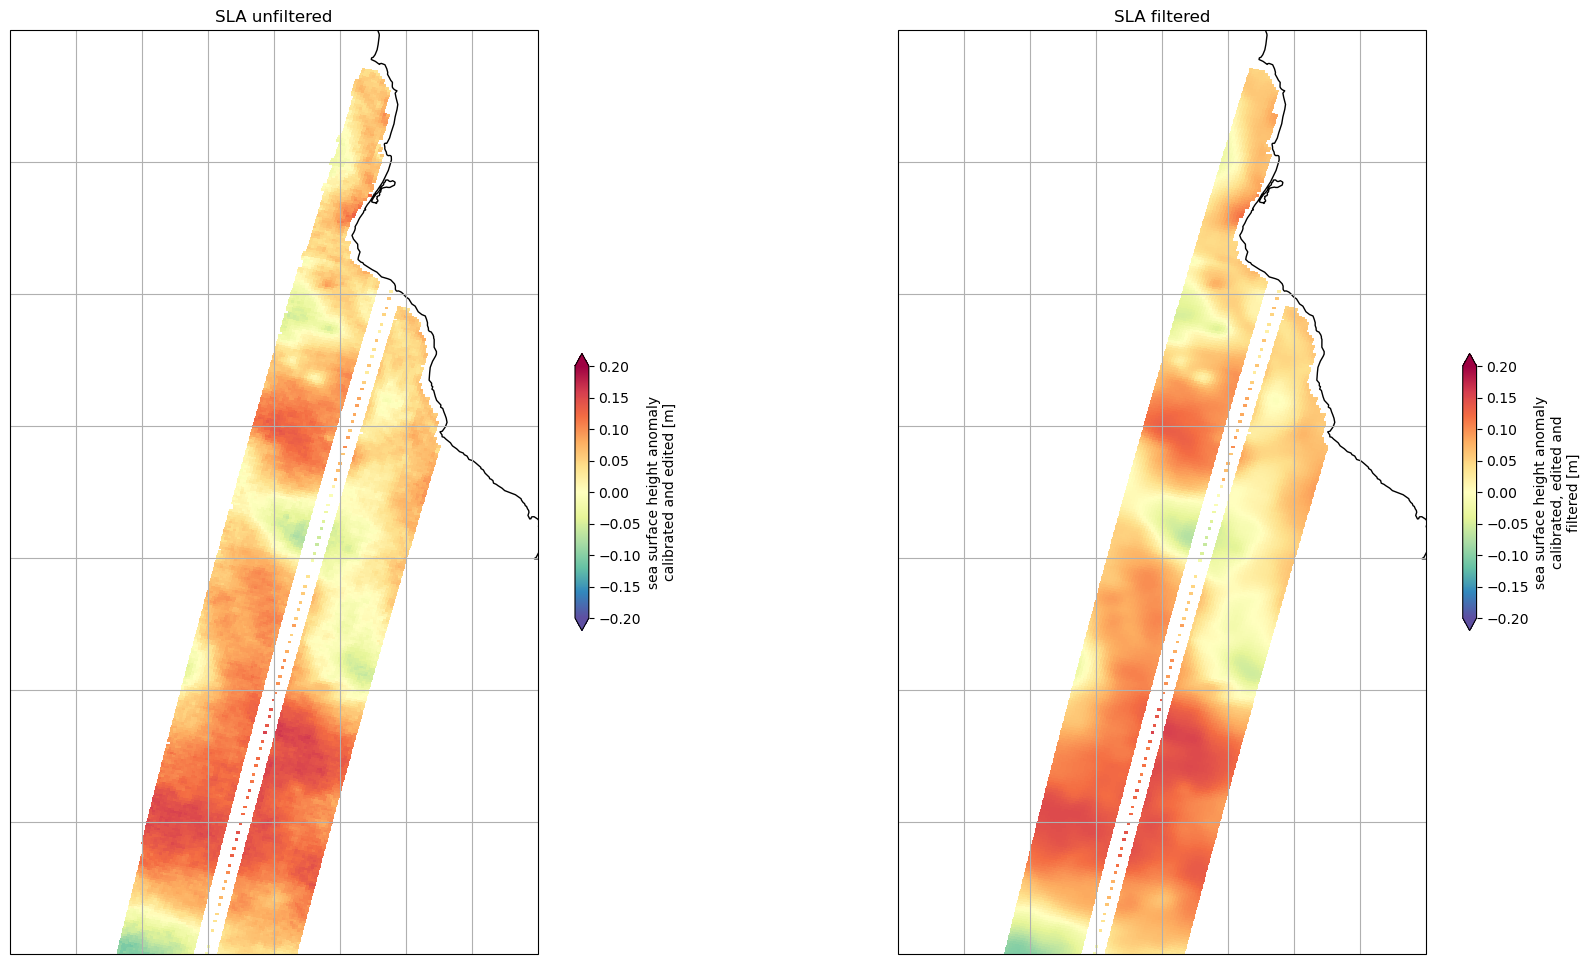

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(21, 12), subplot_kw=dict(projection=ccrs.PlateCarree()))
ax1.set_extent(localbox)
ax2.set_extent(localbox)

plot_kwargs = dict(
    x="longitude",
    y="latitude",
    cmap="Spectral_r",
    vmin=-0.2,
    vmax=0.2,
    cbar_kwargs={"shrink": 0.3},)

# SWOT KaRIn SLA plots
ds_basic.ssha_unfiltered.plot.pcolormesh(ax=ax1, **plot_kwargs)
ds_basic.ssha_filtered.plot.pcolormesh(ax=ax2, **plot_kwargs)

ax1.set_title("SLA unfiltered")
ax1.coastlines()
ax1.gridlines()
ax2.set_title("SLA filtered")
ax2.coastlines()
ax2.gridlines()

### 3.2 Plot sea level anomaly at nadir

The nadir data can be extracted from the dataset using the `i_num_line` and `i_num_pixel` indexes. The nadir positions and time are an estimation that combines the swath positions and time with the indexes.

Create a polygon from localbox, for geographical selection of the data

In [17]:
ds_nadir = alti_data.query_orbit( 
    cycles_nb=cycle_number, 
    passes_nb=pass_number,
    nadir=True,
    swath=False,
    polygon=bbox
)
ds_nadir

INFO:fcollections.implementations.optional._predicates:The bbox intersects with pass numbers (calval phase): [13, 26]
INFO:fcollections.implementations.optional._predicates:The bbox intersects with pass numbers (science phase): [11, 24, 39, 52, 67, 302, 317, 330, 345, 358, 373, 580]
INFO:fcollections.implementations.optional._area_selectors:Size of the dataset matching the bbox: {'num_nadir': 80}


<xarray.Dataset> Size: 4kB
Dimensions:          (num_nadir: 80)
Coordinates:
    time             (num_nadir) datetime64[ns] 640B 2025-06-10T03:32:23.1415...
    latitude         (num_nadir) float64 640B 35.0 35.06 35.18 ... 39.96 40.02
    longitude        (num_nadir) float64 640B 234.5 234.5 234.5 ... 235.9 235.9
Dimensions without coordinates: num_nadir
Data variables:
    mdt              (num_nadir) float64 640B nan nan nan nan ... nan nan nan
    ssha_filtered    (num_nadir) float64 640B -0.014 -0.015 ... 0.058 0.023
    ssha_unfiltered  (num_nadir) float64 640B -0.014 -0.015 ... 0.058 0.023
    i_num_line       (num_nadir) int16 160B 6895 6898 6905 ... 7173 7177 7180
    i_num_pixel      (num_nadir) int8 80B 34 34 34 34 34 34 ... 34 34 34 34 34
    cycle_number     (num_nadir) uint16 160B 34 34 34 34 34 ... 34 34 34 34 34
    pass_number      (num_nadir) uint16 160B 39 39 39 39 39 ... 39 39 39 39 39
Attributes: (12/43)
    Conventions:                     CF-1.9
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    cdm_data_type:                   Swath
    comment:                         Sea Surface Height measured by Altimetry
    data_used:                       SWOT KaRIn L2_LR_SSH PGC0/PIC0/PIC2/PID0...
    doi:                             https://doi.org/10.24400/527896/A01-2023...
    ...                              ...
    geospatial_lon_max:              311.639351
    date_modified:                   2025-11-24T16:35:15Z
    history:                         2025-11-24T16:35:15Z: Created by DUACS K...
    date_created:                    2025-11-24T16:35:15Z
    date_issued:                     2025-11-24T16:35:15Z
    temporality:                     forward

Text(0.5, 1.0, 'SLA Nadir')

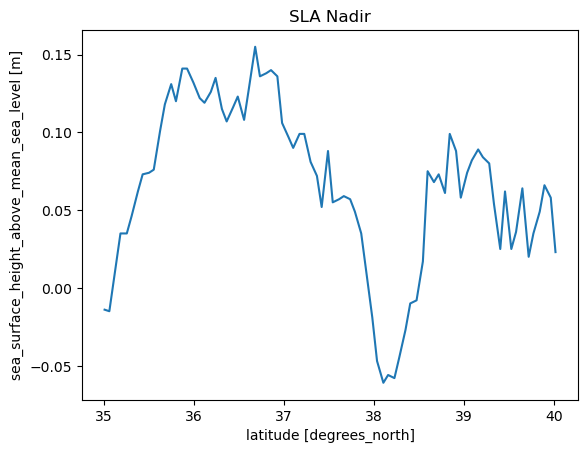

In [18]:
plt.plot(ds_nadir.latitude.values, ds_nadir.ssha_unfiltered.values)
plt.ylabel(f'{ds_nadir.ssha_unfiltered.attrs["standard_name"]} [{ds_nadir.ssha_unfiltered.attrs["units"]}]')
plt.xlabel(f'{ds_nadir.latitude.attrs["standard_name"]} [{ds_nadir.latitude.attrs["units"]}]')
plt.title("SLA Nadir")

### 3.3 Remove sea level anomaly at nadir

It is possible to remove the nadir data combined with L3 KaRIn data.


In [19]:
ds_swath = alti_data.query_orbit( 
    cycles_nb=cycle_number, 
    passes_nb=pass_number,
    nadir=False, 
    swath=True, 
    polygon=bbox
)
ds_swath

INFO:fcollections.implementations.optional._predicates:The bbox intersects with pass numbers (calval phase): [13, 26]
INFO:fcollections.implementations.optional._predicates:The bbox intersects with pass numbers (science phase): [11, 24, 39, 52, 67, 302, 317, 330, 345, 358, 373, 580]
INFO:fcollections.core._readers:Files to read: 1
INFO:fcollections.implementations.optional._area_selectors:Size of the dataset matching the bbox: {'num_lines': 410, 'num_pixels': 69}


<xarray.Dataset> Size: 1MB
Dimensions:          (num_lines: 410, num_pixels: 69)
Coordinates:
    time             (num_lines) datetime64[ns] 3kB dask.array<chunksize=(410,), meta=np.ndarray>
    latitude         (num_lines, num_pixels) float64 226kB dask.array<chunksize=(410, 69), meta=np.ndarray>
    longitude        (num_lines, num_pixels) float64 226kB dask.array<chunksize=(410, 69), meta=np.ndarray>
Dimensions without coordinates: num_lines, num_pixels
Data variables:
    mdt              (num_lines, num_pixels) float64 226kB dask.array<chunksize=(410, 69), meta=np.ndarray>
    ssha_filtered    (num_lines, num_pixels) float64 226kB dask.array<chunksize=(410, 69), meta=np.ndarray>
    ssha_unfiltered  (num_lines, num_pixels) float64 226kB dask.array<chunksize=(410, 69), meta=np.ndarray>
    cycle_number     (num_lines) uint16 820B 34 34 34 34 34 ... 34 34 34 34 34
    pass_number      (num_lines) uint16 820B 39 39 39 39 39 ... 39 39 39 39 39
Attributes: (12/43)
    Conventions:                     CF-1.9
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    cdm_data_type:                   Swath
    comment:                         Sea Surface Height measured by Altimetry
    data_used:                       SWOT KaRIn L2_LR_SSH PGC0/PIC0/PIC2/PID0...
    doi:                             https://doi.org/10.24400/527896/A01-2023...
    ...                              ...
    geospatial_lon_max:              311.639351
    date_modified:                   2025-11-24T16:35:15Z
    history:                         2025-11-24T16:35:15Z: Created by DUACS K...
    date_created:                    2025-11-24T16:35:15Z
    date_issued:                     2025-11-24T16:35:15Z
    temporality:                     forward

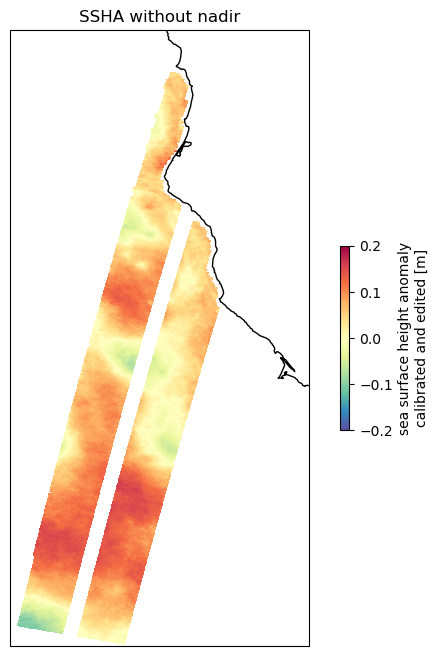

In [20]:
mesh = ds_swath.ssha_unfiltered.plot.pcolormesh(
    figsize=(8, 8),
    subplot_kws=dict(projection=ccrs.PlateCarree()),
    **plot_kwargs
)
mesh.axes.set_title("SSHA without nadir")
mesh.axes.coastlines()

## 4. Expert product



This product contains all the Basic fields, and additional fields that allow a deeper investigation by Expert users. This includes the corrections used for the SLA and the currents (absolute and relative) computed for the denoised SLA.

Open data source

In [21]:
alti_data = AltimetryData(
    source=FileCollectionSource(
        path=output_dir,
        ftype="SWOT_L3_LR_SSH",
        subset="Expert"
    ),
)

Query data with half orbit with geographical selection

In [22]:
ds_expert = alti_data.query_orbit( 
    cycles_nb=cycle_number, 
    passes_nb=pass_number,
    nadir=True,
    swath=True,
    polygon=bbox
)
ds_expert

INFO:fcollections.implementations.optional._predicates:The bbox intersects with pass numbers (calval phase): [13, 26]
INFO:fcollections.implementations.optional._predicates:The bbox intersects with pass numbers (science phase): [11, 24, 39, 52, 67, 302, 317, 330, 345, 358, 373, 580]
INFO:fcollections.core._readers:Files to read: 1
INFO:fcollections.implementations.optional._area_selectors:Size of the dataset matching the bbox: {'num_lines': 410, 'num_pixels': 69}


<xarray.Dataset> Size: 4MB
Dimensions:               (num_lines: 410, num_pixels: 69)
Coordinates:
    time                  (num_lines) datetime64[ns] 3kB dask.array<chunksize=(410,), meta=np.ndarray>
    latitude              (num_lines, num_pixels) float64 226kB dask.array<chunksize=(410, 69), meta=np.ndarray>
    longitude             (num_lines, num_pixels) float64 226kB dask.array<chunksize=(410, 69), meta=np.ndarray>
Dimensions without coordinates: num_lines, num_pixels
Data variables: (12/20)
    calibration           (num_lines, num_pixels) float64 226kB dask.array<chunksize=(410, 69), meta=np.ndarray>
    dac                   (num_lines, num_pixels) float64 226kB dask.array<chunksize=(410, 69), meta=np.ndarray>
    internal_tide         (num_lines, num_pixels) float64 226kB dask.array<chunksize=(410, 69), meta=np.ndarray>
    mdt                   (num_lines, num_pixels) float64 226kB dask.array<chunksize=(410, 69), meta=np.ndarray>
    mss                   (num_lines, num_pixels) float64 226kB dask.array<chunksize=(410, 69), meta=np.ndarray>
    ocean_tide            (num_lines, num_pixels) float64 226kB dask.array<chunksize=(410, 69), meta=np.ndarray>
    ...                    ...
    vgos_filtered         (num_lines, num_pixels) float64 226kB dask.array<chunksize=(410, 69), meta=np.ndarray>
    vgosa_filtered        (num_lines, num_pixels) float64 226kB dask.array<chunksize=(410, 69), meta=np.ndarray>
    vgosa_unfiltered      (num_lines, num_pixels) float64 226kB dask.array<chunksize=(410, 69), meta=np.ndarray>
    cross_track_distance  (num_pixels) float64 552B dask.array<chunksize=(69,), meta=np.ndarray>
    cycle_number          (num_lines) uint16 820B 34 34 34 34 34 ... 34 34 34 34
    pass_number           (num_lines) uint16 820B 39 39 39 39 39 ... 39 39 39 39
Attributes: (12/43)
    Conventions:                     CF-1.9
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    cdm_data_type:                   Swath
    comment:                         Sea Surface Height measured by Altimetry
    data_used:                       SWOT KaRIn L2_LR_SSH PGC0/PIC0/PIC2/PID0...
    doi:                             https://doi.org/10.24400/527896/A01-2023...
    ...                              ...
    geospatial_lon_max:              311.639351
    date_modified:                   2025-11-24T16:35:32Z
    history:                         2025-11-24T16:35:32Z: Created by DUACS K...
    date_created:                    2025-11-24T16:35:32Z
    date_issued:                     2025-11-24T16:35:32Z
    temporality:                     forward

In [23]:
[v for v in ds_expert.variables if v not in ds_basic]

['calibration',
 'dac',
 'internal_tide',
 'mss',
 'ocean_tide',
 'quality_flag',
 'sigma0',
 'ssha_unedited',
 'ugos_filtered',
 'ugosa_filtered',
 'ugosa_unfiltered',
 'vgos_filtered',
 'vgosa_filtered',
 'vgosa_unfiltered',
 'cross_track_distance']

### 4.1 Sea level anomalies
Let's visualize SWOT KaRIn abd Nadir data using cartopy.
Adapt this code to visualize other variables or regions, or try importing another file.

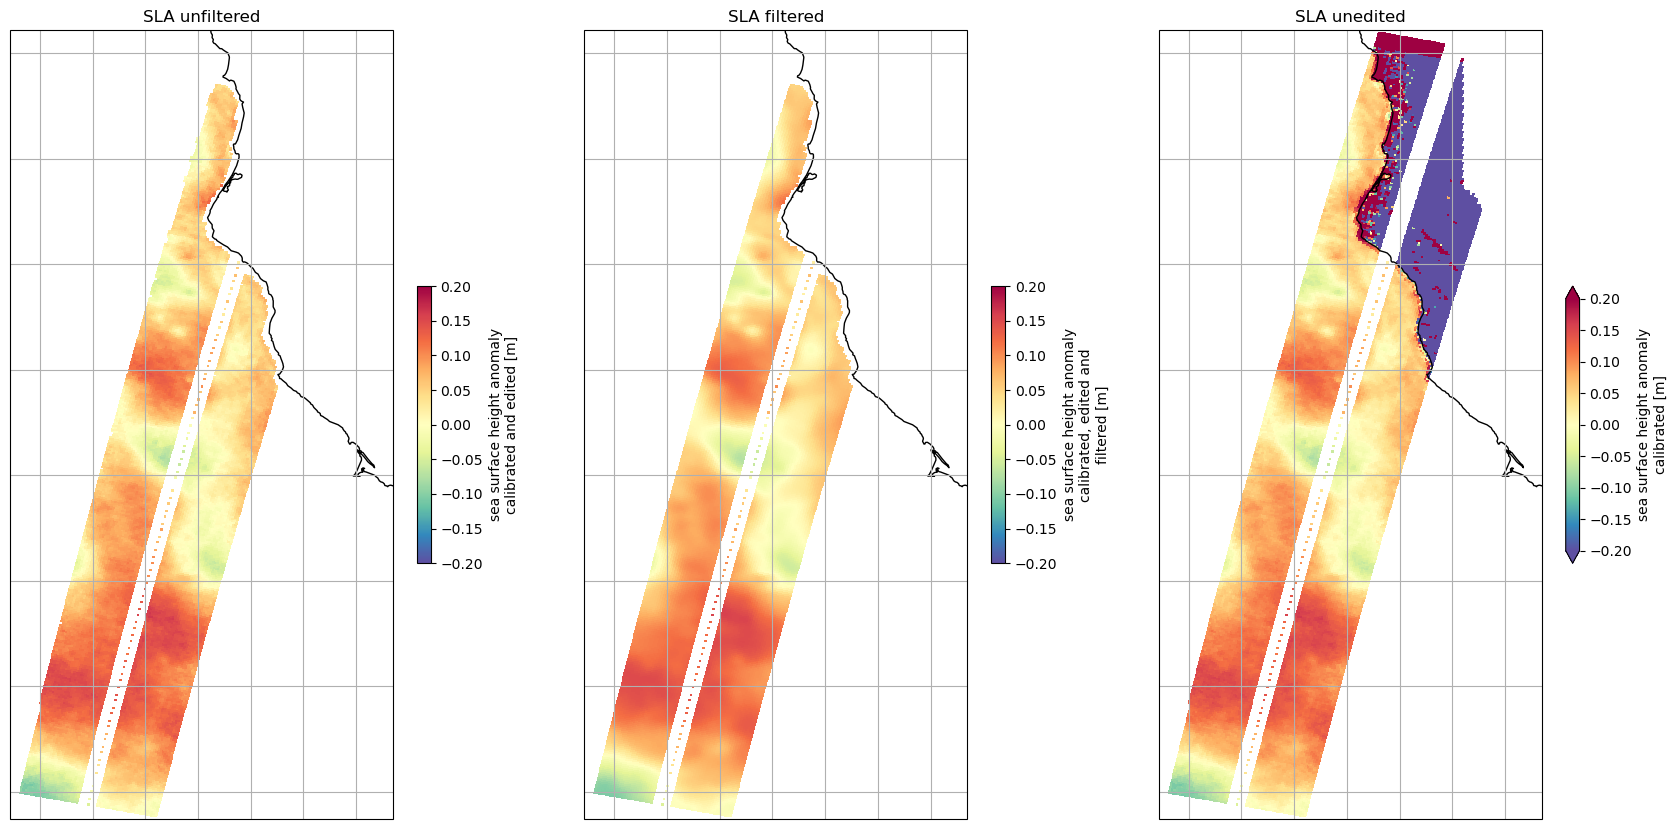

In [24]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(21, 12), subplot_kw=dict(projection=ccrs.PlateCarree()))

plot_kwargs = dict(
    x="longitude",
    y="latitude",
    cmap="Spectral_r",
    vmin=-0.2,
    vmax=0.2,
    cbar_kwargs={"shrink": 0.3},)

# SWOT KaRIn SLA plots
ds_expert.ssha_unfiltered.plot.pcolormesh(ax=ax1, **plot_kwargs)
ds_expert.ssha_filtered.plot.pcolormesh(ax=ax2, **plot_kwargs)
ds_expert.ssha_unedited.plot.pcolormesh(ax=ax3, **plot_kwargs)

ax1.set_title("SLA unfiltered")
ax1.coastlines()
ax1.gridlines()
ax2.set_title("SLA filtered")
ax2.coastlines()
ax2.gridlines()
ax3.set_title("SLA unedited")
ax3.coastlines()
ax3.gridlines()

### 4.2 Sigma 0

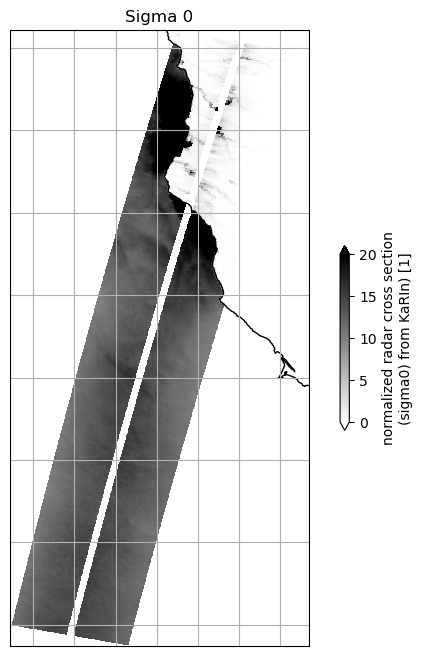

In [25]:
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection=ccrs.PlateCarree()))
# ax.set_extent(localbox)

plot_kwargs = dict(
    x="longitude",
    y="latitude",
    cmap="gray_r",
    vmin=0,
    vmax=20,
    cbar_kwargs={"shrink": 0.3},)

# SWOT KaRIn SLA plots
ds_expert.sigma0.plot.pcolormesh(ax=ax, **plot_kwargs)

ax.set_title("Sigma 0")
ax.coastlines()
ax.gridlines()